<a href="https://colab.research.google.com/github/Sargam2808/DEEP_LEARNING_LAB/blob/main/Dl_lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Experiment 7 - Sequence-to-Sequence Learning with Transformers (English → Spanish)**

Enabling GPU

In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Uploading Dataset (spa.txt)

In [2]:
from google.colab import files
files.upload()

Saving spa.txt to spa.txt


{'spa.txt': b'Go.\tVe.\nGo.\tVete.\nGo.\tVaya.\nGo.\tV\xc3\xa1yase.\nHi.\tHola.\nRun!\t\xc2\xa1Corre!\nRun.\tCorred.\nWho?\t\xc2\xbfQui\xc3\xa9n?\nFire!\t\xc2\xa1Fuego!\nFire!\t\xc2\xa1Incendio!\nFire!\t\xc2\xa1Disparad!\nHelp!\t\xc2\xa1Ayuda!\nHelp!\t\xc2\xa1Socorro! \xc2\xa1Auxilio!\nHelp!\t\xc2\xa1Auxilio!\nJump!\t\xc2\xa1Salta!\nJump.\tSalte.\nStop!\t\xc2\xa1Parad!\nStop!\t\xc2\xa1Para!\nStop!\t\xc2\xa1Pare!\nWait!\t\xc2\xa1Espera!\nWait.\tEsperen.\nGo on.\tContin\xc3\xbaa.\nGo on.\tContin\xc3\xbae.\nHello!\tHola.\nI ran.\tCorr\xc3\xad.\nI ran.\tCorr\xc3\xada.\nI try.\tLo intento.\nI won!\t\xc2\xa1He ganado!\nOh no!\t\xc2\xa1Oh, no!\nRelax.\tTom\xc3\xa1telo con soda.\nSmile.\tSonr\xc3\xade.\nAttack!\t\xc2\xa1Al ataque!\nAttack!\t\xc2\xa1Atacad!\nGet up.\tLevanta.\nGo now.\tVe ahora mismo.\nGot it!\t\xc2\xa1Lo tengo!\nGot it?\t\xc2\xbfLo pillas?\nGot it?\t\xc2\xbfEntendiste?\nHe ran.\t\xc3\x89l corri\xc3\xb3.\nHop in.\tM\xc3\xa9tete adentro.\nHug me.\tAbr\xc3\xa1zame.\nI fell.\tMe c

In [3]:
!pip install sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.0 MB/s eta 0:00:00


Installing and Importing Libraries

In [4]:
import torch.nn as nn
import torch.optim as optim
import math, random, time
import sacrebleu
import matplotlib.pyplot as plt
from collections import Counter

Loading Dataset

In [5]:
def load_data(path, max_samples=10000):
    pairs = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            eng, spa = line.strip().lower().split('\t')
            pairs.append((eng, spa))
    return pairs[:max_samples]

data = load_data("/content/spa.txt")
print("Total sentence pairs:", len(data))
print("Sample:", data[0])

Total sentence pairs: 10000
Sample: ('go.', 've.')


**DATASET INFORMATION & VISUALIZATION**

Sentence Length Distribution

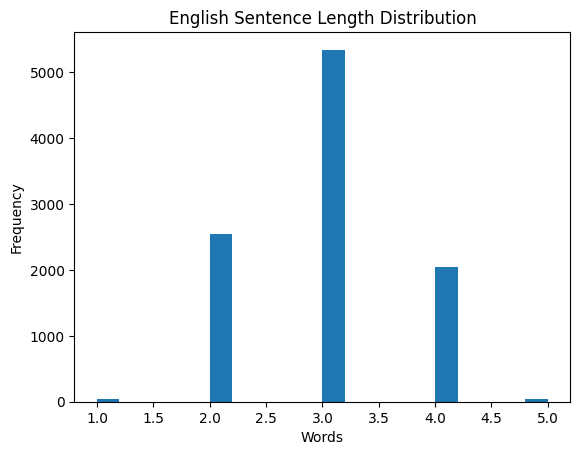

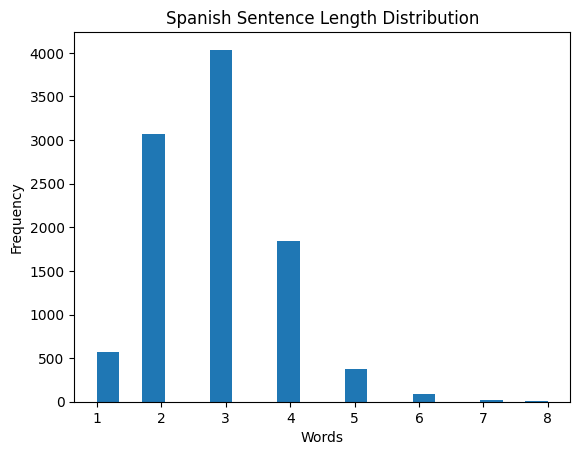

Max English length: 5
Max Spanish length: 8


In [6]:
eng_lengths = [len(x[0].split()) for x in data]
spa_lengths = [len(x[1].split()) for x in data]

plt.figure()
plt.hist(eng_lengths, bins=20)
plt.title("English Sentence Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(spa_lengths, bins=20)
plt.title("Spanish Sentence Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

print("Max English length:", max(eng_lengths))
print("Max Spanish length:", max(spa_lengths))

Train / Validation / Test Split

In [7]:
random.shuffle(data)

train_size = int(0.8 * len(data))
val_size = int(0.1 * len(data))

train_data = data[:train_size]
val_data = data[train_size:train_size+val_size]
test_data = data[train_size+val_size:]

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 8000
Validation: 1000
Test: 1000


Vocabulary Creation

In [8]:
def build_vocab(sentences, min_freq=2):
    counter = Counter()
    for s in sentences:
        counter.update(s.split())

    vocab = {'<pad>':0, '<sos>':1, '<eos>':2, '<unk>':3}
    idx = 4
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab

src_vocab = build_vocab([x[0] for x in train_data])
tgt_vocab = build_vocab([x[1] for x in train_data])

SRC_VOCAB_SIZE = len(src_vocab)
TGT_VOCAB_SIZE = len(tgt_vocab)

print("English vocab size:", SRC_VOCAB_SIZE)
print("Spanish vocab size:", TGT_VOCAB_SIZE)

English vocab size: 1618
Spanish vocab size: 2101


Vocabulary Size Visualization

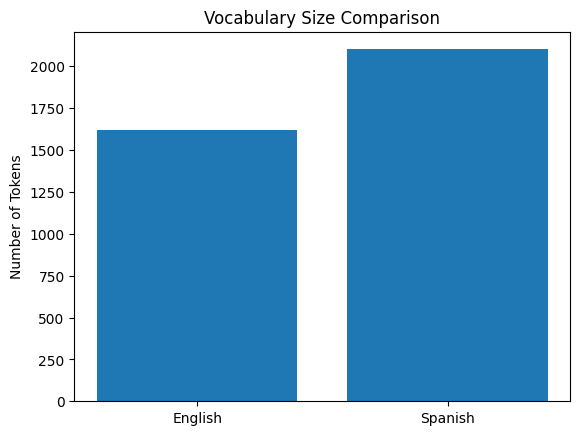

In [9]:
plt.bar(["English", "Spanish"], [SRC_VOCAB_SIZE, TGT_VOCAB_SIZE])
plt.title("Vocabulary Size Comparison")
plt.ylabel("Number of Tokens")
plt.show()

Encoding & Padding

In [19]:
MAX_LEN = 20

def encode(sentence, vocab):
    return [vocab.get(w, vocab['<unk>']) for w in sentence.split()]

def pad(seq):
    seq = seq[:MAX_LEN]
    return seq + [0] * (MAX_LEN - len(seq))

def prepare_batch(data, batch_size=64):
    batch = random.sample(data, batch_size)
    src_batch, tgt_batch = [], []

    for src, tgt in batch:
        src_seq = pad(encode(src, src_vocab))

        tgt_seq = (
            [tgt_vocab['<sos>']] +
            encode(tgt, tgt_vocab) +
            [tgt_vocab['<eos>']]
        )
        tgt_seq = pad(tgt_seq)

        src_batch.append(src_seq)
        tgt_batch.append(tgt_seq)

    return torch.tensor(src_batch), torch.tensor(tgt_batch)

**TRANSFORMER MODEL**

Positional Encoding

In [20]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

Transformer Encoder–Decoder

In [21]:
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.src_embed = nn.Embedding(SRC_VOCAB_SIZE, 256)
        self.tgt_embed = nn.Embedding(TGT_VOCAB_SIZE, 256)
        self.pos = PositionalEncoding(256)

        self.transformer = nn.Transformer(
            d_model=256,
            nhead=8,
            num_encoder_layers=3,
            num_decoder_layers=3,
            dim_feedforward=512,
            batch_first=True
        )

        self.fc = nn.Linear(256, TGT_VOCAB_SIZE)

    def forward(self, src, tgt):
        src = self.pos(self.src_embed(src))
        tgt = self.pos(self.tgt_embed(tgt))
        out = self.transformer(src, tgt)
        return self.fc(out)

Training Loop (10 Epochs)

In [31]:
from math import ceil

model = TransformerModel().to(device)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=0.0003)

EPOCHS = 10
BATCH_SIZE = 64
losses = []

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    random.shuffle(train_data)

    for i in range(0, len(train_data), BATCH_SIZE):
        batch = train_data[i:i+BATCH_SIZE]
        src, tgt = prepare_batch(batch)
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()
        output = model(src, tgt[:, :-1])
        loss = criterion(
            output.reshape(-1, TGT_VOCAB_SIZE),
            tgt[:, 1:].reshape(-1)
        )
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / ceil(len(train_data)/BATCH_SIZE)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

Epoch 1/10, Loss: 4.3211
Epoch 2/10, Loss: 2.4957
Epoch 3/10, Loss: 1.7310
Epoch 4/10, Loss: 1.2621
Epoch 5/10, Loss: 0.9176
Epoch 6/10, Loss: 0.6527
Epoch 7/10, Loss: 0.4415
Epoch 8/10, Loss: 0.2887
Epoch 9/10, Loss: 0.1826
Epoch 10/10, Loss: 0.1096


Training Loss Visualization

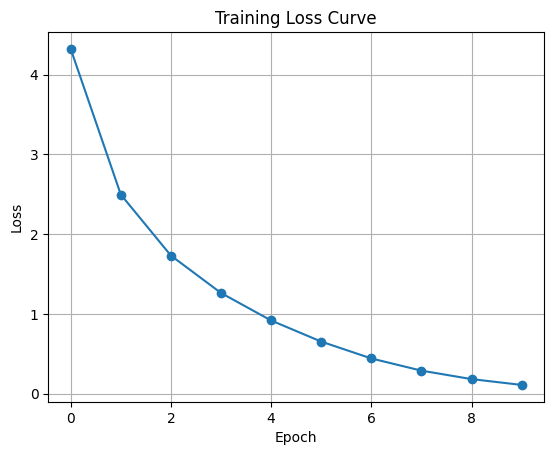

In [32]:
plt.plot(losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

Translation Function

In [33]:
def translate(sentence):
    model.eval()
    src = torch.tensor([pad(encode(sentence, src_vocab))]).to(device)
    tgt = torch.tensor([[tgt_vocab['<sos>']]]).to(device)

    generated = []

    for _ in range(MAX_LEN):
        out = model(src, tgt)
        next_word = out[:, -1, :].argmax(-1).item()

        if next_word == tgt_vocab['<eos>']:
            break

        generated.append(next_word)
        tgt = torch.cat([tgt, torch.tensor([[next_word]]).to(device)], dim=1)

    return generated

Translation Output Visualization

In [34]:
inv_tgt_vocab = {v:k for k,v in tgt_vocab.items()}

for i in range(5):
    eng, ref = test_data[i]
    pred_ids = translate(eng)
    pred_words = [inv_tgt_vocab[i] for i in pred_ids]

    print("English   :", eng)
    print("Reference :", ref)
    print("Predicted :", " ".join(pred_words))
    print("-"*50)

English   : he went abroad.
Reference : se fue al extranjero.
Predicted : ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes
--------------------------------------------------
English   : i'm not kidding.
Reference : no estoy bromeando.
Predicted : ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes
--------------------------------------------------
English   : we'll do it.
Reference : lo haremos.
Predicted : ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes
--------------------------------------------------
English   : it's windy.
Reference : hace viento.
Predicted : ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes ustedes us

BLEU Score

In [35]:
refs, hyps = [], []

for eng, spa in test_data[:100]:
    pred_ids = translate(eng)
    pred_words = [inv_tgt_vocab[i] for i in pred_ids]
    hyps.append(" ".join(pred_words))
    refs.append([spa])

print("BLEU score:", sacrebleu.corpus_bleu(hyps, refs))

BLEU score: BLEU = 0.00 0.0/0.0/0.0/0.0 (BP = 1.000 ratio = 3.333 hyp_len = 20 ref_len = 6)


Execution Time

In [36]:
print("Total execution time (minutes):", (time.time() - start_time) / 60)

Total execution time (minutes): 1.8875617543856302
